In [83]:
import torch
from torch import nn, inference_mode
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

import numpy as np

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.13.0
0.28.0


In [84]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

mps


In [85]:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True,transform=ToTensor())
test_data = datasets.FashionMNIST(root='./data', train=False, download=True,transform=ToTensor())

In [86]:
len(train_data), len(test_data)

(60000, 10000)

In [87]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [88]:
batch_size = 32
trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [89]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3,stride=1, padding=1)
        # (28 - 3 + 2*1 )/ 1 + 1 = 28
        # 28 /2 = 14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3,stride=1, padding=1)
        # (14 - 3 + 2*1 )/ 1 + 1 = 14
        # 28 /2 = 7

        self.linear1 = nn.Linear(64*7*7, 128)
        self.linear2 = nn.Linear(128, 10)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.linear1(x))
        x = self.linear2(x)

        return x

model = Net()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [90]:
x,y = next(iter(trainloader))

y_hat = model(x)
y_hat.shape

torch.Size([32, 10])

In [91]:
model.to(device)

epochs = 10

train_loss = []
test_loss = []

train_acc = []
test_acc = []

for epoch in range(epochs):

    model.train()

    train_batch_loss = []
    train_batch_acc = []

    for x, y in trainloader:

        x = x.to(device)
        y = y.to(device)

        y_hat = model(x)
        loss = loss_fn(y_hat, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_batch_loss.append(loss.item())

        # compute accuracy
        matches = torch.argmax(y_hat, dim=1) == y
        matches = matches.float()
        train_batch_acc.append(100*torch.mean(matches).item())

    train_loss.append(np.mean(train_batch_loss))
    train_acc.append(np.mean(train_batch_acc))

    model.eval()

    test_batch_loss = []
    test_batch_acc = []

    with torch.no_grad():
        for x, y in testloader:
            x =x.to(device)
            y = y.to(device)

            y_hat = model(x)
            loss = loss_fn(y_hat, y)

            test_batch_loss.append(loss.item())

            matches = torch.argmax(y_hat, dim=1) == y
            matches = matches.float()
            test_batch_acc.append(100*torch.mean(matches).item())

    test_loss.append(np.mean(test_batch_loss))
    test_acc.append(np.mean(test_batch_acc))

    print(f'Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss[-1]:.2f} | Test Loss: {test_loss[-1]:.2f} | Train Accuracy: {train_acc[-1]:.2f}  | Test Accuracy: {test_acc[-1]:.2f}' )


Epoch: 1/10 | Train Loss: 0.84 | Test Loss: 0.60 | Train Accuracy: 69.36  | Test Accuracy: 77.35
Epoch: 2/10 | Train Loss: 0.54 | Test Loss: 0.49 | Train Accuracy: 80.04  | Test Accuracy: 82.42
Epoch: 3/10 | Train Loss: 0.46 | Test Loss: 0.45 | Train Accuracy: 83.37  | Test Accuracy: 83.36
Epoch: 4/10 | Train Loss: 0.41 | Test Loss: 0.43 | Train Accuracy: 85.07  | Test Accuracy: 84.45
Epoch: 5/10 | Train Loss: 0.38 | Test Loss: 0.39 | Train Accuracy: 86.25  | Test Accuracy: 85.85
Epoch: 6/10 | Train Loss: 0.36 | Test Loss: 0.37 | Train Accuracy: 87.03  | Test Accuracy: 86.95
Epoch: 7/10 | Train Loss: 0.34 | Test Loss: 0.36 | Train Accuracy: 87.77  | Test Accuracy: 87.31
Epoch: 8/10 | Train Loss: 0.32 | Test Loss: 0.36 | Train Accuracy: 88.39  | Test Accuracy: 86.90
Epoch: 9/10 | Train Loss: 0.31 | Test Loss: 0.34 | Train Accuracy: 88.86  | Test Accuracy: 87.58
Epoch: 10/10 | Train Loss: 0.29 | Test Loss: 0.36 | Train Accuracy: 89.28  | Test Accuracy: 87.45


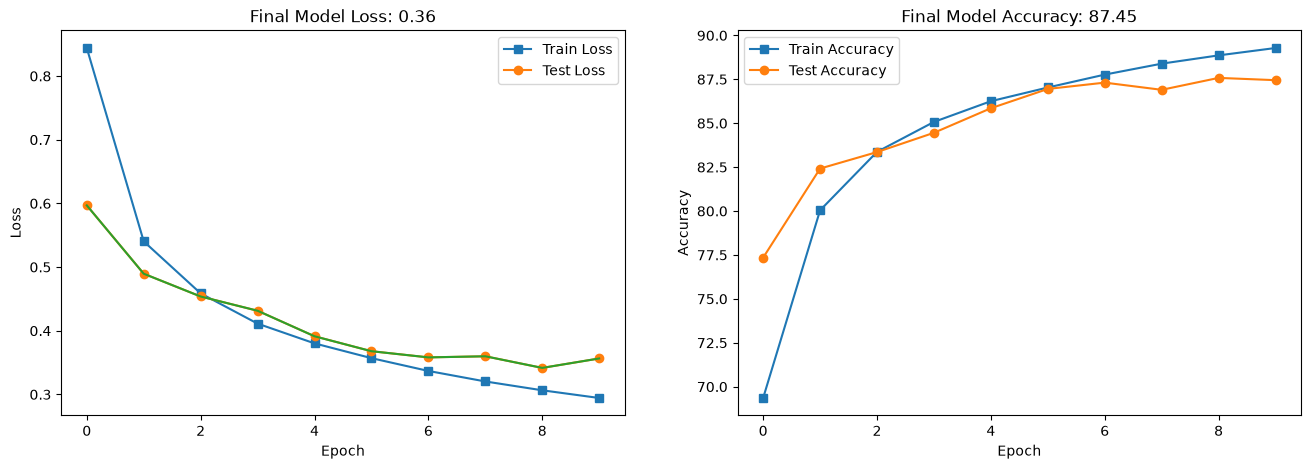

In [92]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_loss, 's-' , label='Train Loss')
ax[0].plot(test_loss, 'o-' , label='Test Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].plot(test_loss)
ax[0].set_title(f'Final Model Loss: {test_loss[-1]:.2f}')
ax[0].legend()

ax[1].plot(train_acc, 's-', label='Train Accuracy')
ax[1].plot(test_acc, 'o-', label='Test Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title(f'Final Model Accuracy: {test_acc[-1]:.2f}')
ax[1].legend()

plt.show()